In [ ]:
import sys
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
from datasets import load_dataset

from src.objects import AlignmentProblem, LatentSpace
from src.objects.latent import DimReductionMethod
from src.plotting.latent import plot_pc_correlation_heatmap


def _check_models_in_registry(model_a: str, model_b: str) -> None:
    """Check if models exist in the model registry."""
    model_df = pl.read_parquet('hf://datasets/spaicom-lab/model-registry/**/*.parquet')
    available_models = set(model_df['model_name'].unique().to_list())

    missing = []
    if model_a not in available_models:
        missing.append(model_a)
    if model_b not in available_models:
        missing.append(model_b)

    if missing:
        raise ValueError(
            f'Model(s) not found in model registry: {missing}\n'
            f'Available models: {sorted(available_models)[:20]}... (showing first 20)'
        )


def _check_models_in_dataset(model_a: str, model_b: str, dataset: str) -> None:
    """Check if models have embeddings in the dataset."""
    from datasets import get_dataset_config_names

    try:
        available = set(get_dataset_config_names(dataset))

        missing = []
        if model_a not in available:
            missing.append(model_a)
        if model_b not in available:
            missing.append(model_b)

        if missing:
            raise ValueError(
                f'Model(s) not found in dataset {dataset}: {missing}\n'
                f'Use scripts/encode_dataset_all_timm.py to encode missing models.'
            )
    except Exception as e:
        if isinstance(e, ValueError):
            raise
        raise ValueError(f'Error checking dataset {dataset}: {e}') from e


def _load_latent(model: str, dataset: str) -> LatentSpace:
    """Load latent embeddings from HuggingFace dataset."""
    data = load_dataset(dataset, model, split='test').with_format('torch')
    latent = torch.vstack(list(data['embedding']))
    return LatentSpace(latent, seed=42)


def main(
    model_a: str,
    model_b: str,
    dataset: str,
    method: DimReductionMethod,
    n_components: int = 50,
    k: int | None = None,
    n_anchors: int | None = None,
    output_path: str | None = None,
    repo_id: str = 'spaicom-lab',
    prefix: str = 'semantic-',
) -> None:
    """Plot correlation heatmap between principal components of two models."""

    _check_models_in_registry(model_a, model_b)

    full_dataset = f'{repo_id}/{prefix}{dataset}'
    _check_models_in_dataset(model_a, model_b, full_dataset)

    latent_a = _load_latent(model_a, full_dataset)
    latent_b = _load_latent(model_b, full_dataset)

    if n_anchors is not None:
        print(f'Aligning via relative representation (n_anchors={n_anchors}) ...')
        latent_a, latent_b = AlignmentProblem(latent_a, latent_b).align(
            'relative',
            strategy='prototype',
            n_anchors=n_anchors,
        )

    fig, ax = plot_pc_correlation_heatmap(
        latent_a=latent_a,
        latent_b=latent_b,
        method=method,
        n_components=n_components,
        k=k,
        label_a=model_a,
        label_b=model_b,
    )

    if n_anchors is not None:
        ax.set_title(
            ax.get_title().replace(
                'PC correlation', f'PC correlation (relative, {n_anchors} anchors)'
            ),
            fontsize=10,
            pad=8,
        )

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f'Saved heatmap to {output_path}')
    else:
        fig.show()


In [ ]:
beit3_base_patch16_224.in22k_ft_in1k
vit_base_patch16_224.augreg_in1k
vit_base_patch16_384.augreg_in1k
vit_base_patch16_224.augreg_in21k
vit_base_patch32_224.augreg_in21k
vit_small_patch16_224.augreg_in1k

In [ ]:
# repo_id = 'spaicom-lab'
# prefix = 'semantic-'
# dataset_id: str = cfg.dataset.name.split('/')[-1]
# dataset: str = f'{cfg.repo_id}/{cfg.prefix}{dataset_id}'
# cache_pattern: str = f'{cfg.repo_id}___{cfg.prefix}{dataset_id}'
# hub_pattern: str = f'datasets--{cfg.repo_id}--{cfg.prefix}{dataset_id}*'


# import polars as pl

# model = "vit_base"
# models: list[str] = (
#     pl.read_parquet('hf://datasets/spaicom-lab/model-registry/**/*.parquet')
#     # .filter(pl.col('latent_dim') < cfg.preprocess.max_latent)
#     .filter((model is None) | pl.col('model_name').str.contains(model))
#     .select('model_name')
#     .unique()
#     .sort('model_name')['model_name']
#     .to_list()
# )
# models

['convit_base.fb_in1k',
 'crossvit_base_240.in1k',
 'davit_base.msft_in1k',
 'davit_base_fl.msft_florence2',
 'flexivit_base.1000ep_in21k',
 'flexivit_base.1200ep_in1k',
 'flexivit_base.300ep_in1k',
 'flexivit_base.300ep_in21k',
 'flexivit_base.600ep_in1k',
 'flexivit_base.patch16_in21k',
 'flexivit_base.patch30_in21k',
 'gcvit_base.in1k',
 'maxvit_base_tf_224.in1k',
 'maxvit_base_tf_224.in21k',
 'maxvit_base_tf_384.in1k',
 'maxvit_base_tf_384.in21k_ft_in1k',
 'maxvit_base_tf_512.in1k',
 'maxvit_base_tf_512.in21k_ft_in1k',
 'naflexvit_base_patch16_gap.e300_s576_in1k',
 'naflexvit_base_patch16_par_gap.e300_s576_in1k',
 'naflexvit_base_patch16_parfac_gap.e300_s576_in1k',
 'naflexvit_base_patch16_siglip.v2_webli',
 'nextvit_base.bd_in1k',
 'nextvit_base.bd_in1k_384',
 'nextvit_base.bd_ssld_6m_in1k',
 'nextvit_base.bd_ssld_6m_in1k_384',
 'samvit_base_patch16.sa1b',
 'vit_base_mci_224.apple_mclip',
 'vit_base_mci_224.apple_mclip2_dfndr2b',
 'vit_base_mci_224.apple_mclip_lt',
 'vit_base_patc

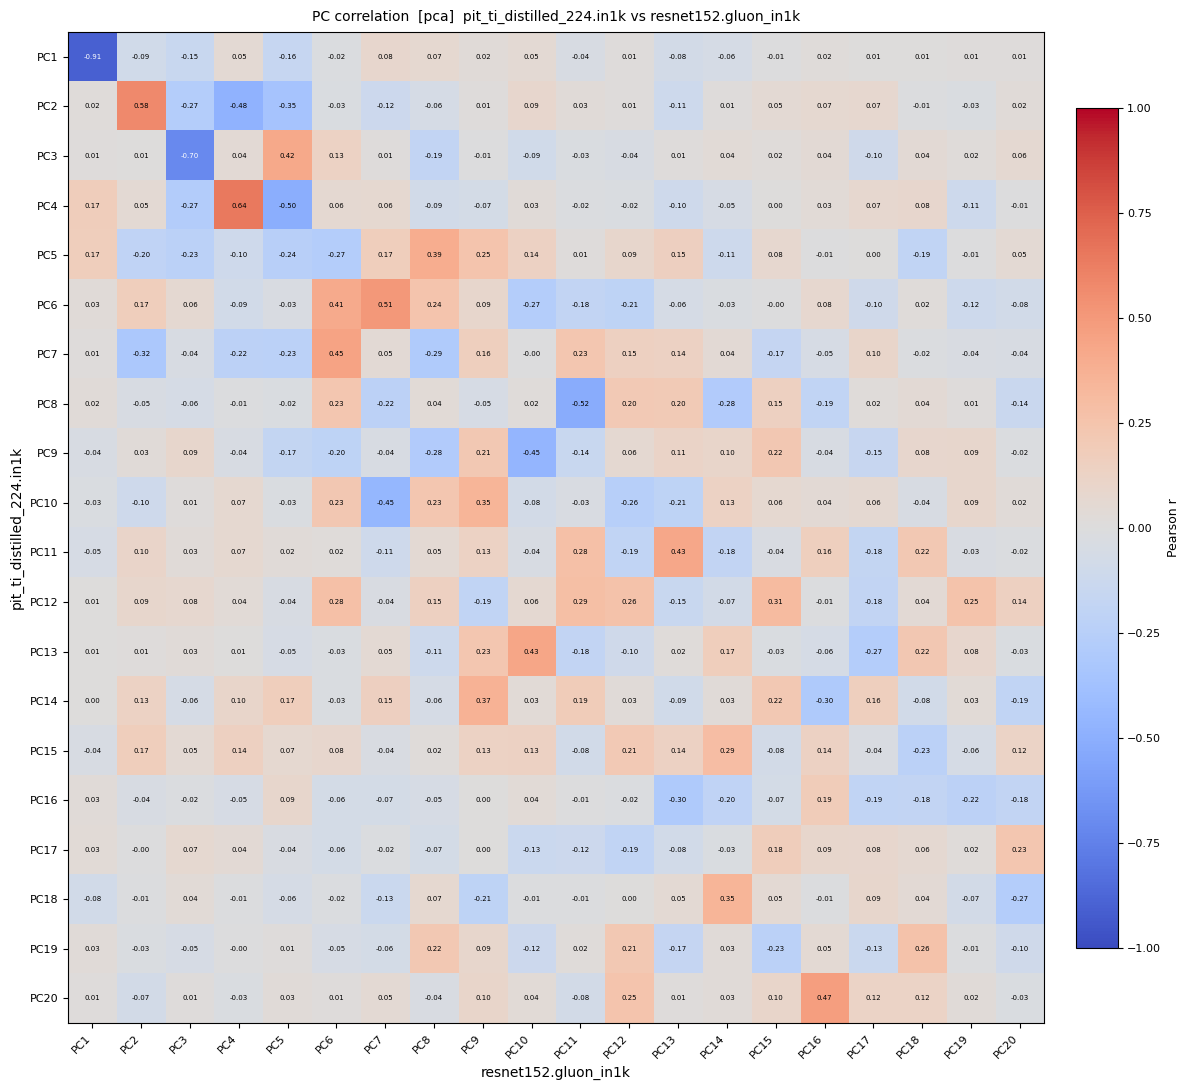

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'pit_ti_distilled_224.in1k'
model_b = 'resnet152.gluon_in1k'
method = 'pca'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)


Aligning via relative representation (n_anchors=20) ...


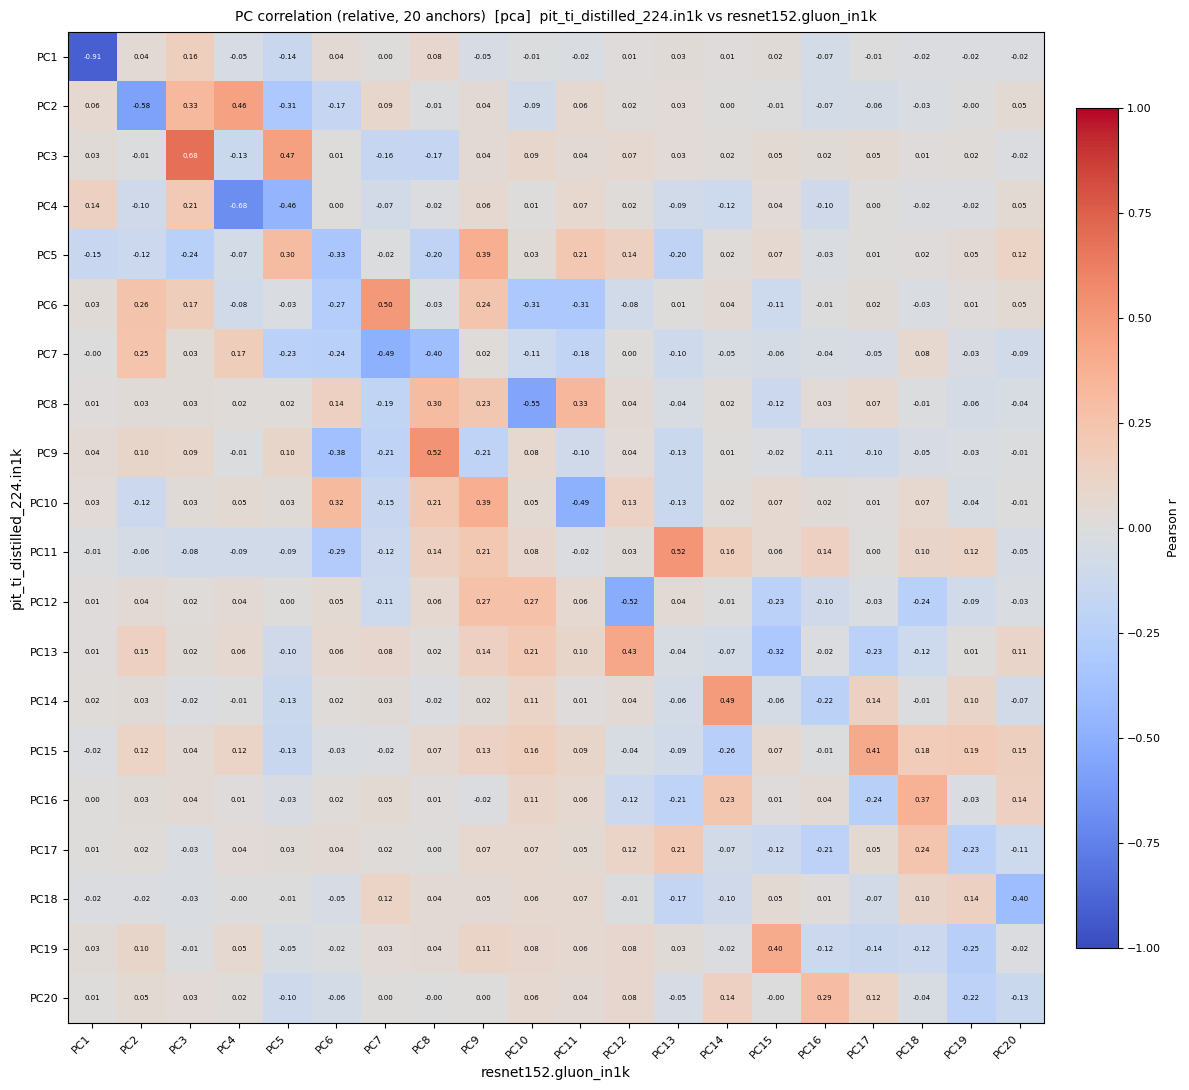

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'pit_ti_distilled_224.in1k'
model_b = 'resnet152.gluon_in1k'
method = 'pca'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    n_anchors=20,
    output_path=None,
)

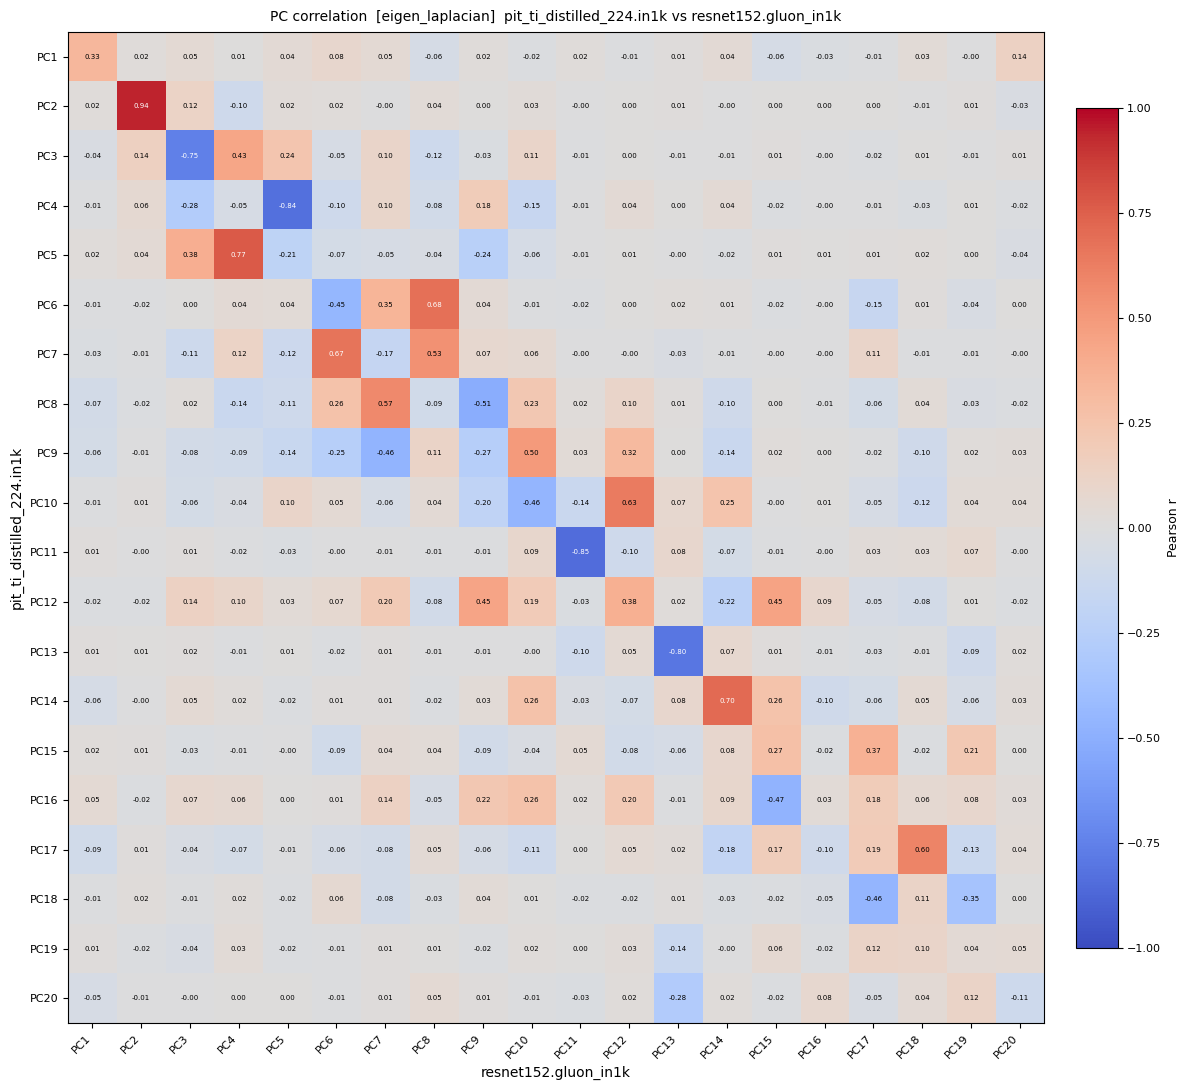

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'pit_ti_distilled_224.in1k'
model_b = 'resnet152.gluon_in1k'
method = 'eigen_laplacian'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)

Aligning via relative representation (n_anchors=20) ...


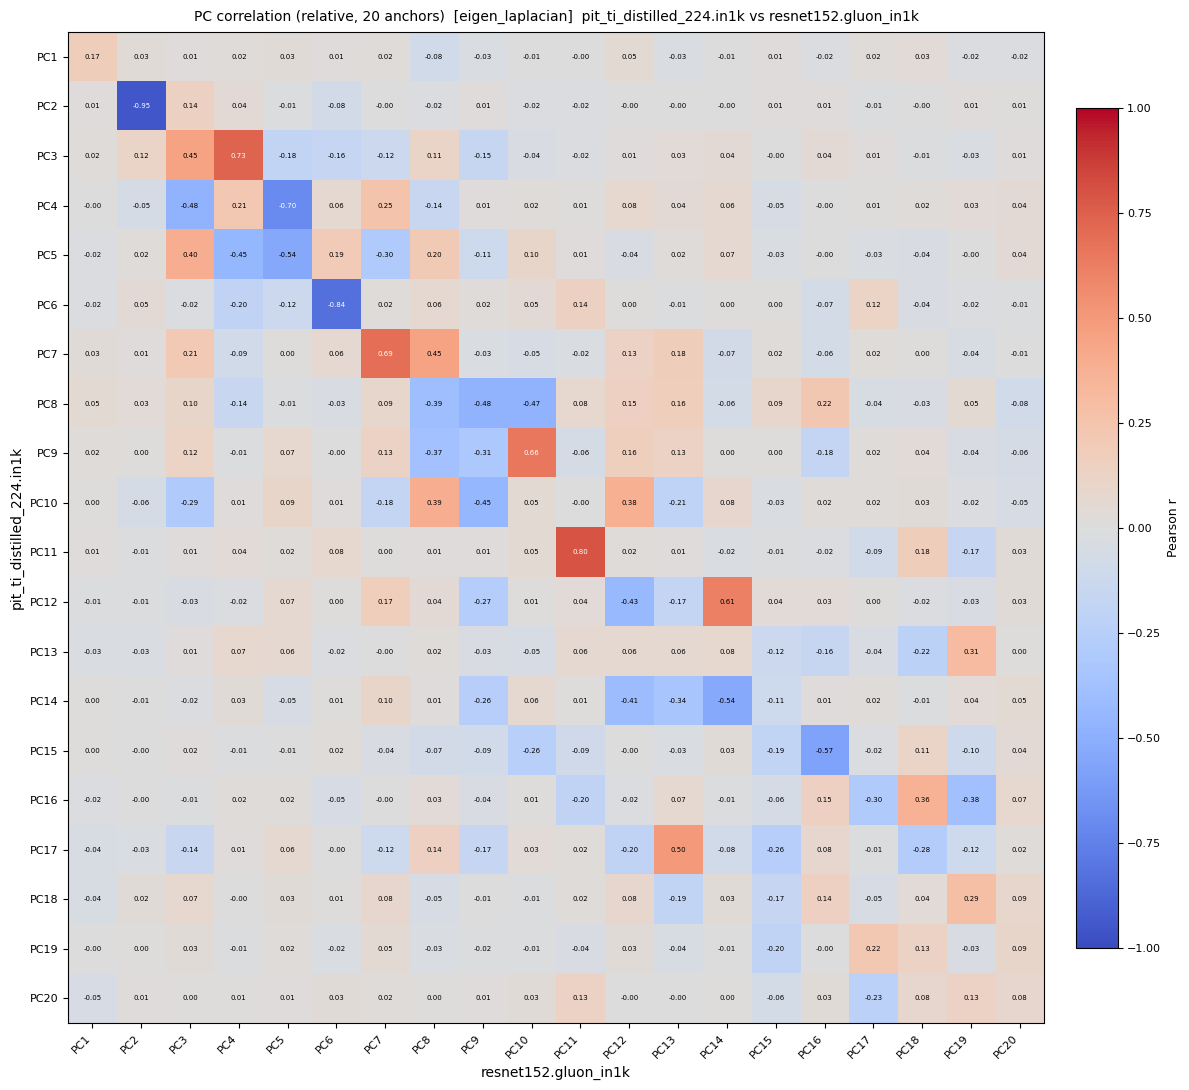

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'pit_ti_distilled_224.in1k'
model_b = 'resnet152.gluon_in1k'
method = 'eigen_laplacian'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    n_anchors=20,
    output_path=None,
)

train/pit_ti_224.in1k/part-00000.parquet:   0%|          | 0.00/47.6M [00:00<?, ?B/s]

test/pit_ti_224.in1k/part-00000.parquet:   0%|          | 0.00/9.53M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

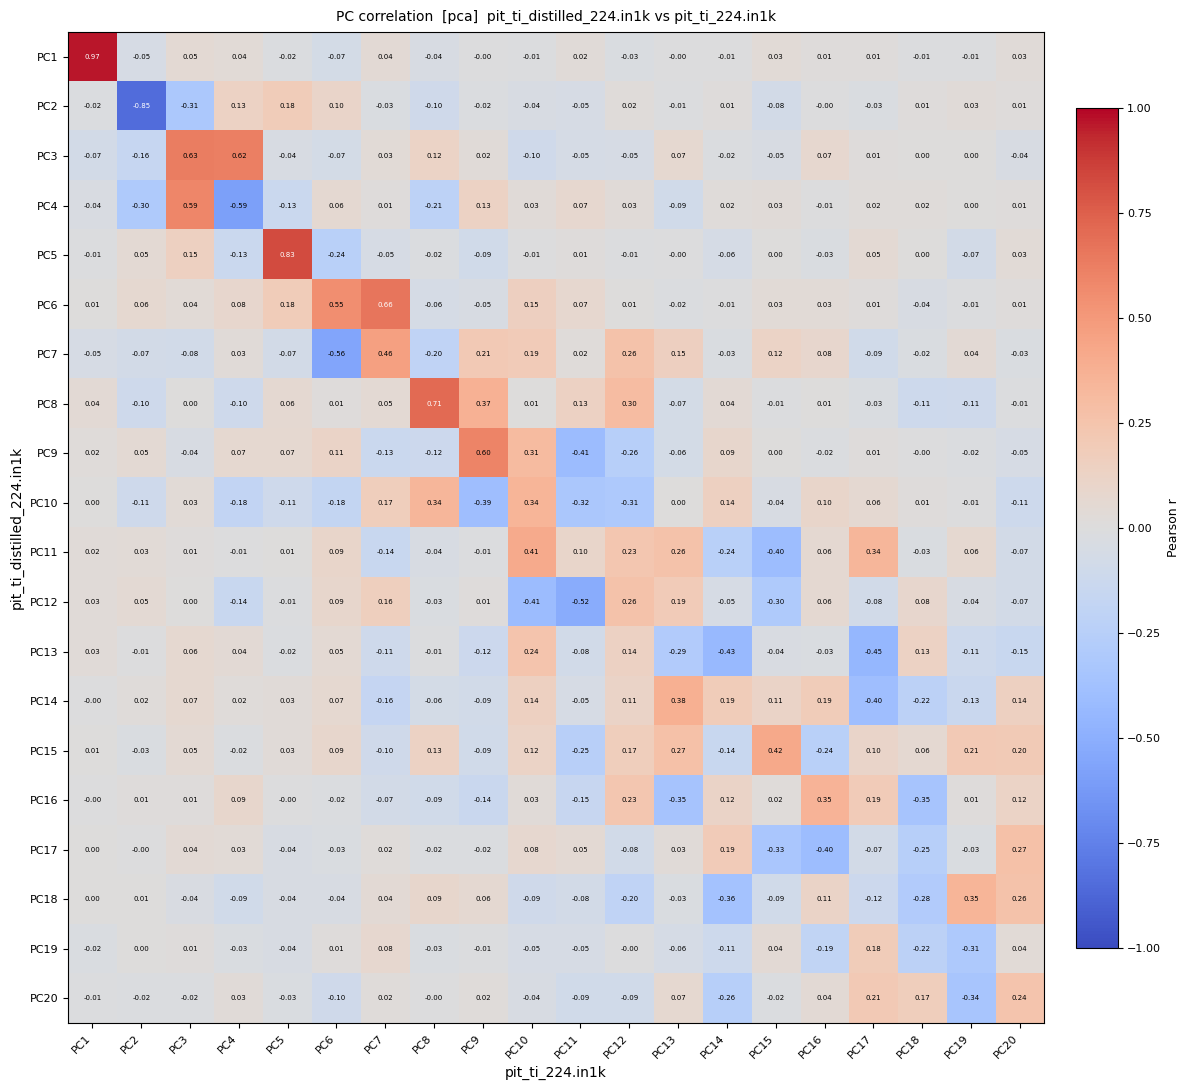

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'pit_ti_distilled_224.in1k'
model_b = 'pit_ti_224.in1k'
method = 'pca'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)

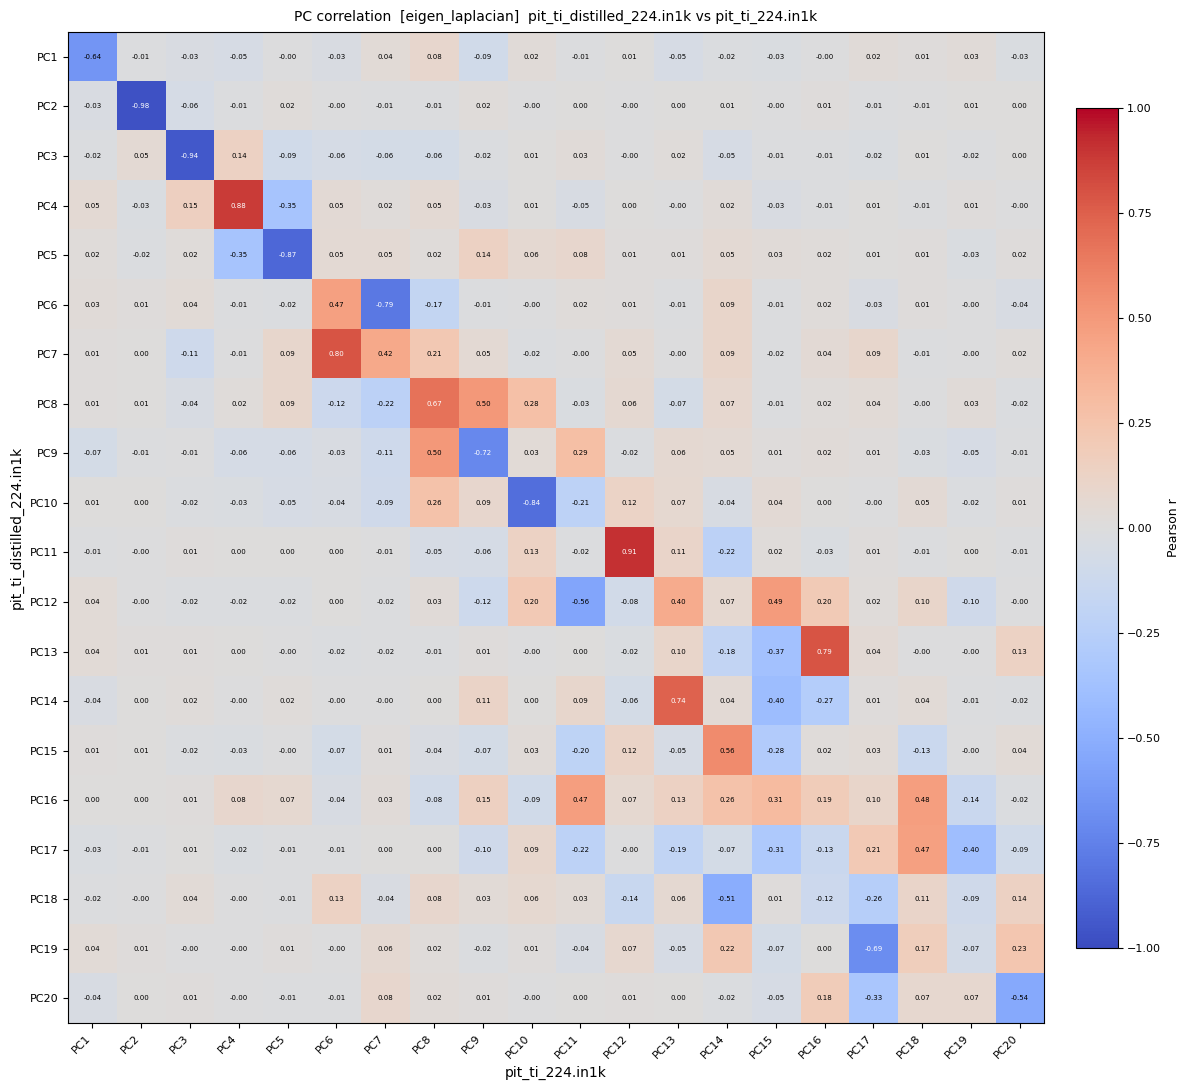

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'pit_ti_distilled_224.in1k'
model_b = 'pit_ti_224.in1k'
method = 'eigen_laplacian'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)

train/resnet152s.gluon_in1k/part-00000.p(…):   0%|          | 0.00/371M [00:00<?, ?B/s]

test/resnet152s.gluon_in1k/part-00000.pa(…):   0%|          | 0.00/74.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

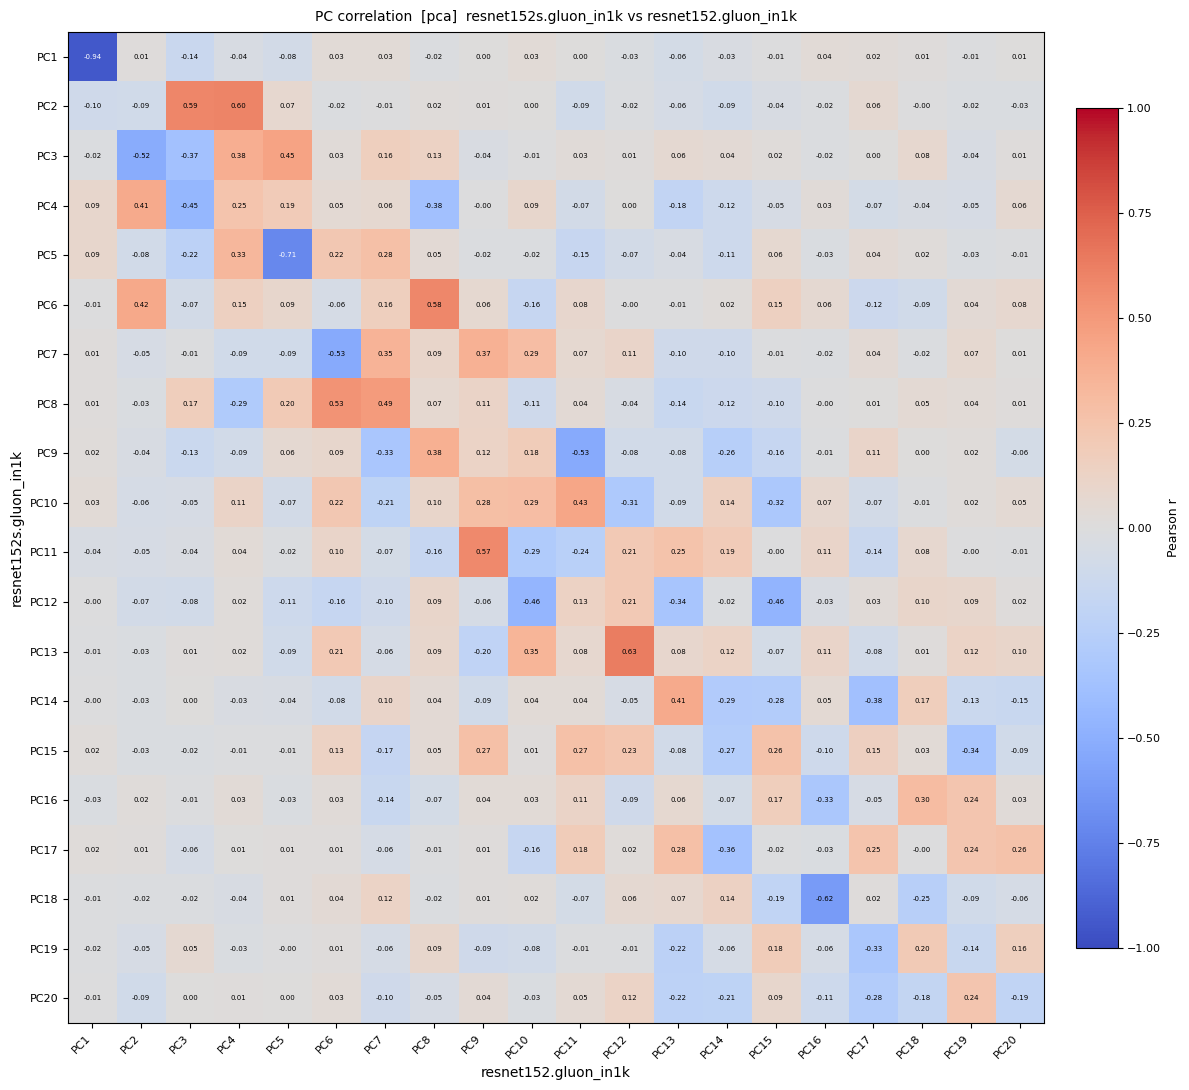

In [ ]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
model_a = 'resnet152s.gluon_in1k'
model_b = 'resnet152.gluon_in1k'
method = 'pca'
n_components = 20
k = 20
main(
    model_a=model_a,
    model_b=model_b,
    dataset=dataset,
    method=method,
    n_components=n_components,
    k=k,
    output_path=None,
)


In [10]:
import logging
import sys
import sys
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from src.plotting.tda import plot_persistence_diagram, plot_persistence_images


def plot_tda_results(repo_id, prefix, dataset, model_pattern):
    RESULTS_DIR = PROJECT_ROOT / Path('results/tda_signatures')
    OUTPUT_DIR = PROJECT_ROOT / Path('results/tda_plots')
    repo_dataset = f'{repo_id}__{prefix}{dataset}'
    pattern = f'{repo_dataset}__*.parquet'

    df = pl.read_parquet(RESULTS_DIR / pattern)
    if df.is_empty():
        print(f'No files found matching: {RESULTS_DIR / pattern}')

    if model_pattern:
        df = df.filter(pl.col('model').str.contains(model_pattern))

    if df.is_empty():
        print(f'No rows left after filtering model ~ {model_pattern!r}')

    print(f'Plotting {len(df)} row(s) | model filter: {model_pattern or "none"}')
    max_dim = 2
    n_dims = max_dim + 1

    for row in df.iter_rows(named=True):
        model_name: str = row['model']
        split: str = row['split']

        out_dir = OUTPUT_DIR / dataset / model_name
        out_dir.mkdir(parents=True, exist_ok=True)

        pts = np.array(row['persistence_diagram'])  # (n_pts, 3): [birth, death, dim]
        images_nested = row[
            'persistence_image'
        ]  # list[list[list[float]]] (n_dims, n_bins, n_bins)

        # --- persistence diagram ---
        fig_diag, ax_diag = plt.subplots(figsize=(6, 6))
        plot_persistence_diagram(
            ax_diag,
            pts,
            title=f'{model_name} | {dataset} | {split}',
        )
        fig_diag.tight_layout()
        diag_path = out_dir / f'{split}__persistence_diagram.png'
        # fig_diag.savefig(diag_path, dpi=150)
        plt.show()
        print(f'  Saved: {diag_path}')

        # --- persistence images ---
        fig_img, axes_img = plt.subplots(1, n_dims, figsize=(5 * n_dims, 5))
        axes_list = [axes_img] if n_dims == 1 else list(axes_img)
        fig_img.suptitle(
            f'Persistence Images – {model_name} | {dataset} | {split}',
            fontsize=10,
        )
        plot_persistence_images(axes_list, images_nested, max_dim)
        fig_img.tight_layout()
        img_path = out_dir / f'{split}__persistence_image.png'
        # fig_img.savefig(img_path, dpi=150)
        print(f'  Saved: {img_path}')
        plt.show()

Plotting 1 row(s) | model filter: pit_ti_distilled_224.in1k


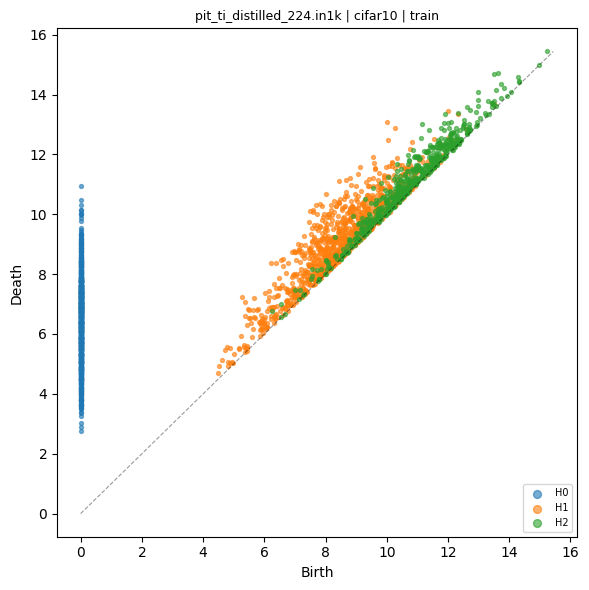

  Saved: /home/engrima/projects/semantic-datasets/results/tda_plots/cifar10/pit_ti_distilled_224.in1k/train__persistence_diagram.png
  Saved: /home/engrima/projects/semantic-datasets/results/tda_plots/cifar10/pit_ti_distilled_224.in1k/train__persistence_image.png


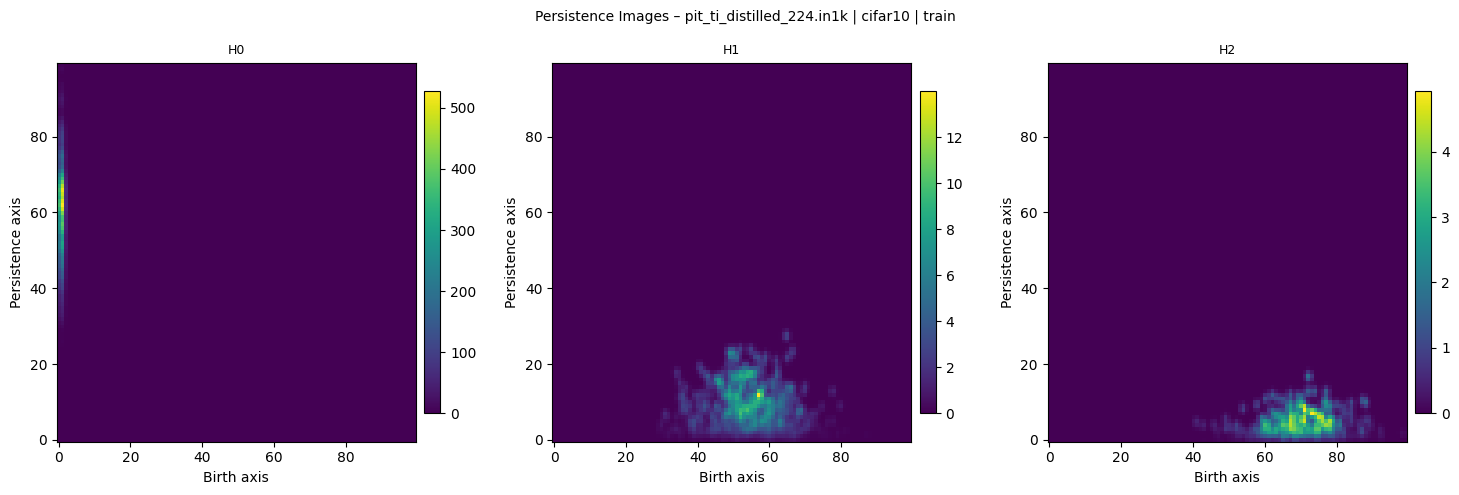

In [11]:
repo_id = 'spaicom-lab'
prefix = 'semantic-'
dataset = 'cifar10'
model_pattern = 'pit_ti_distilled_224.in1k'

plot_tda_results(
    repo_id=repo_id, prefix=prefix, dataset=dataset, model_pattern=model_pattern
)


Plotting 1 row(s) | model filter: pit_ti_224.in1k


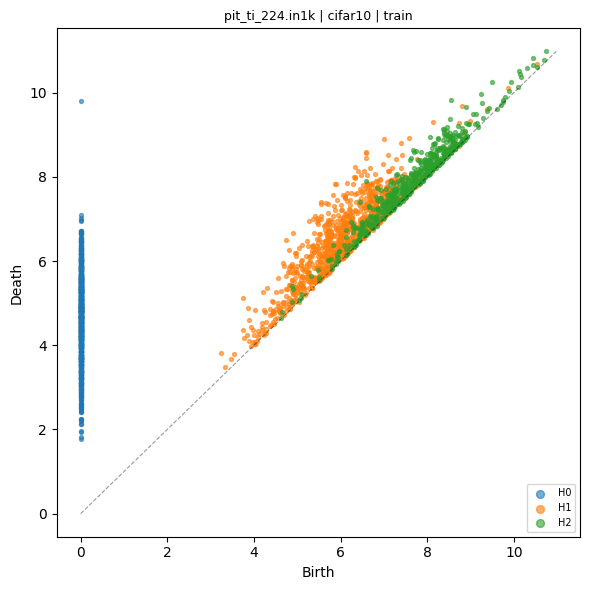

  Saved: /home/engrima/projects/semantic-datasets/results/tda_plots/cifar10/pit_ti_224.in1k/train__persistence_diagram.png
  Saved: /home/engrima/projects/semantic-datasets/results/tda_plots/cifar10/pit_ti_224.in1k/train__persistence_image.png


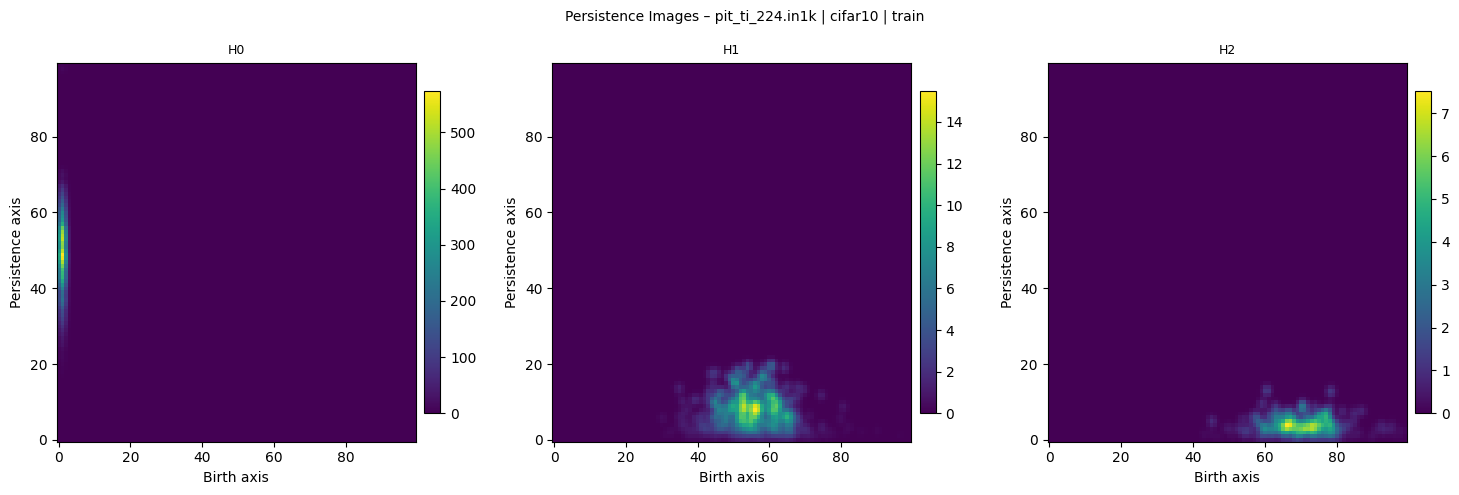

In [ ]:
logging.getLogger('httpx').setLevel(logging.WARNING)

repo_id = 'spaicom-lab'
prefix = 'semantic-'
dataset = 'cifar10'
model_pattern = 'pit_ti_224.in1k'  # "resnet34.gluon_in1k"

plot_tda_results(
    repo_id=repo_id, prefix=prefix, dataset=dataset, model_pattern=model_pattern
)


Plotting 1 row(s) | model filter: skresnet34.ra_in1k


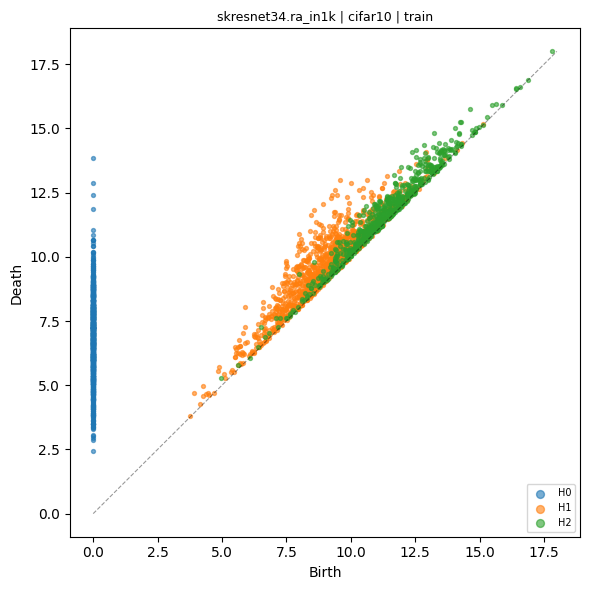

  Saved: /home/engrima/projects/semantic-datasets/results/tda_plots/cifar10/skresnet34.ra_in1k/train__persistence_diagram.png
  Saved: /home/engrima/projects/semantic-datasets/results/tda_plots/cifar10/skresnet34.ra_in1k/train__persistence_image.png


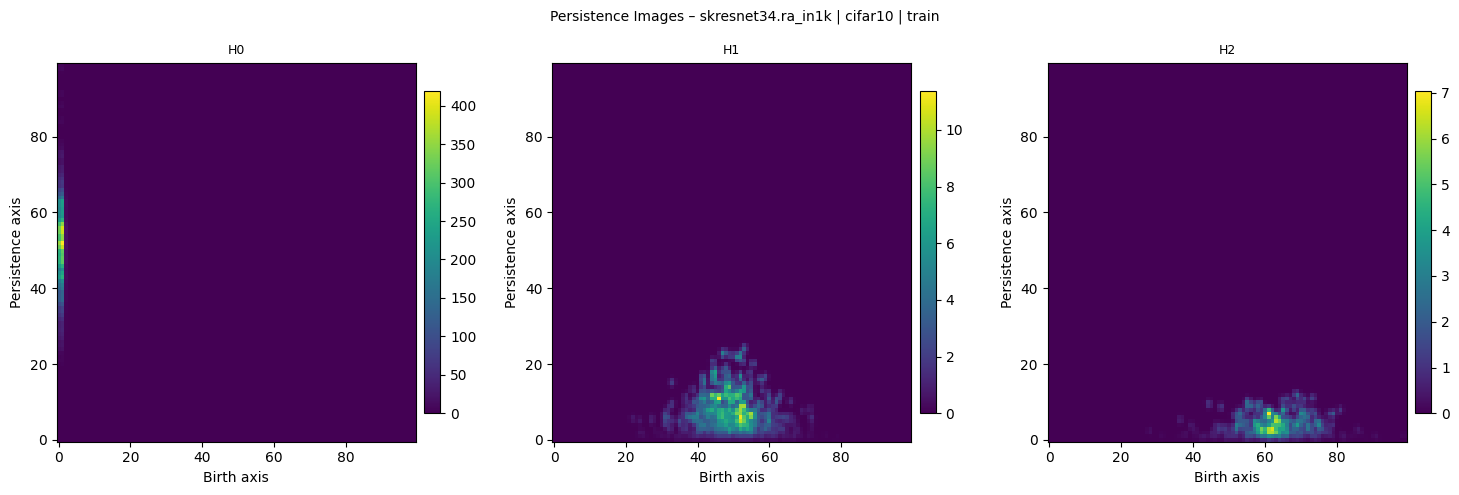

In [ ]:
logging.getLogger('httpx').setLevel(logging.WARNING)

repo_id = 'spaicom-lab'
prefix = 'semantic-'
dataset = 'cifar10'
model_pattern = 'skresnet34.ra_in1k'

plot_tda_results(
    repo_id=repo_id, prefix=prefix, dataset=dataset, model_pattern=model_pattern
)


In [18]:
import itertools
import sys
from pathlib import Path

import numpy as np
import polars as pl

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset

from src.objects import AlignmentProblem, LatentSpace
from src.objects.latent import DimReductionMethod
from src.plotting.latent import _pearson_cross_correlation


def _check_models_in_registry(models: list[str]) -> None:
    model_df = pl.read_parquet('hf://datasets/spaicom-lab/model-registry/**/*.parquet')
    available_models = set(model_df['model_name'].unique().to_list())
    missing = [m for m in models if m not in available_models]
    if missing:
        raise ValueError(
            f'Model(s) not found in model registry: {missing}\n'
            f'Available models: {sorted(available_models)[:20]}... (showing first 20)'
        )


def _check_models_in_dataset(models: list[str], dataset: str) -> None:
    from datasets import get_dataset_config_names

    try:
        available = set(get_dataset_config_names(dataset))
        missing = [m for m in models if m not in available]
        if missing:
            raise ValueError(
                f'Model(s) not found in dataset {dataset}: {missing}\n'
                f'Use scripts/encode_dataset_all_timm.py to encode missing models.'
            )
    except Exception as e:
        if isinstance(e, ValueError):
            raise
        raise ValueError(f'Error checking dataset {dataset}: {e}') from e


def _load_raw(model: str, dataset: str) -> np.ndarray:
    """Load embeddings as a plain float32 numpy array (no LatentSpace wrapper)."""
    data = load_dataset(dataset, model, split='test').with_format('torch')
    return torch.vstack(list(data['embedding'])).float().numpy()


def _correlation_matrix(
    latent_a: LatentSpace,
    latent_b: LatentSpace,
    method: DimReductionMethod,
    n_components: int,
    k: int | None,
    seed: int = 42,
) -> np.ndarray:
    latent_a.compute_principal_components(
        method=method, n_components=n_components, k=k, seed=seed
    )
    latent_b.compute_principal_components(
        method=method, n_components=n_components, k=k, seed=seed
    )

    k_eff_a = latent_a.pc_embedding.shape[1]
    k_eff_b = latent_b.pc_embedding.shape[1]
    k_use = min(k if k is not None else k_eff_a, k_eff_a, k_eff_b)

    return _pearson_cross_correlation(
        latent_a.pc_embedding[:, :k_use],
        latent_b.pc_embedding[:, :k_use],
    )


def compare_latents(
    models: list[str],
    dataset: str,
    method: DimReductionMethod,
    n_components: int = 50,
    k: int | None = None,
    n_anchors: int | None = None,
    output_path: str | None = None,
    repo_id: str = 'spaicom-lab',
    prefix: str = 'semantic-',
    figsize: tuple[float, float] = (20, 8),
    cmap: str = 'coolwarm',
) -> tuple[plt.Figure, np.ndarray]:
    """Plot a 2×5 grid of PC-correlation heatmaps for all pairs of 5 models.

    Parameters
    ----------
    models:
        Exactly 5 model names (produces 10 unique pairs).
    output_path:
        If provided, save the figure to this path instead of displaying it.
    """
    if len(models) < 2:
        raise ValueError('Need at least 2 models.')

    _check_models_in_registry(models)
    full_dataset = f'{repo_id}/{prefix}{dataset}'
    _check_models_in_dataset(models, full_dataset)

    # Cache raw arrays only — LatentSpace objects are created fresh per pair so
    # that AlignmentProblem mutations (prewhitening, prototype frames) never
    # leak across pairs.
    print(f'Loading {len(models)} latent spaces...')
    raw: dict[str, np.ndarray] = {m: _load_raw(m, full_dataset) for m in models}

    pairs = list(itertools.combinations(models, 2))
    n_pairs = len(pairs)
    n_cols = 5
    n_rows = (n_pairs + n_cols - 1) // n_cols

    print(f'Computing {n_pairs} correlation matrices...')
    matrices: list[tuple[str, str, np.ndarray]] = []
    for model_a, model_b in pairs:
        # Fresh LatentSpace per pair — alignment mutates internal state
        # (prewhitening, Parseval frame) and must not bleed into other pairs.
        la = LatentSpace(raw[model_a], seed=42)
        lb = LatentSpace(raw[model_b], seed=42)

        if n_anchors is not None:
            la, lb = AlignmentProblem(la, lb).align(
                'relative',
                strategy='prototype',
                n_anchors=n_anchors,
            )

        C = _correlation_matrix(la, lb, method, n_components, k)
        matrices.append((model_a, model_b, C))

    vmin, vmax = -1.0, 1.0

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = axes.ravel()

    title_suffix = f'  [relative, {n_anchors} anchors]' if n_anchors else ''
    fig.suptitle(
        f'PC correlation  [{method}]{title_suffix}',
        fontsize=13,
        y=1.01,
    )

    im = None
    for idx, (model_a, model_b, C) in enumerate(matrices):
        ax = axes_flat[idx]
        im = ax.imshow(C, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(model_b, fontsize=7, labelpad=3)
        ax.set_ylabel(model_a, fontsize=7, labelpad=3)

    for idx in range(n_pairs, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.tight_layout()
    cbar = fig.colorbar(
        im,
        ax=axes_flat[:n_pairs].tolist(),
        shrink=0.7,
        pad=0.02,
    )
    cbar.set_label('Pearson r', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {output_path}')
    else:
        plt.show()

    return fig, axes


Loading 5 latent spaces...
Computing 10 correlation matrices...


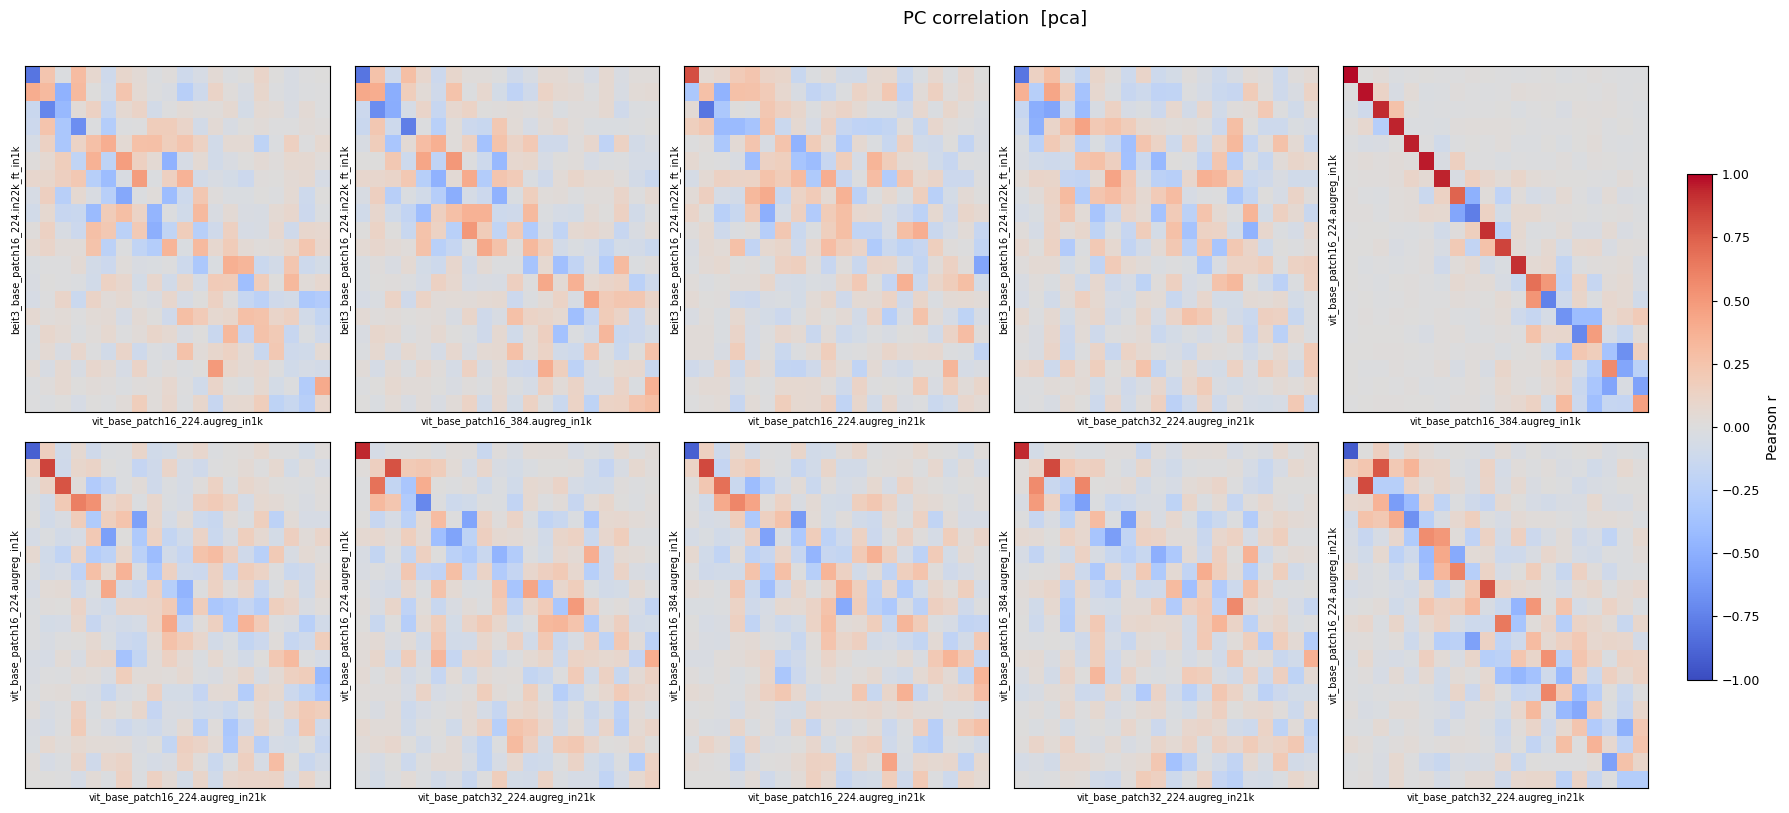

(<Figure size 2000x800 with 11 Axes>,
 array([[<Axes: xlabel='vit_base_patch16_224.augreg_in1k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_384.augreg_in1k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_384.augreg_in1k', ylabel='vit_base_patch16_224.augreg_in1k'>],
        [<Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='vit_base_patch16_224.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='vit_base_patch16_224.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='vit_base_patch16_384.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='vit_base_patch16_384.augreg_in1k'>,
         <Ax

In [19]:
dataset = 'cifar10'
# model_a = "vit_base_patch32_384.augreg_in1k"
models = [
    'beit3_base_patch16_224.in22k_ft_in1k',
    'vit_base_patch16_224.augreg_in1k',  # architecture change
    'vit_base_patch16_384.augreg_in1k',  # padding change
    'vit_base_patch16_224.augreg_in21k',  # pretraining change
    'vit_base_patch32_224.augreg_in21k',
]
method = 'pca'
n_components = 20
k = 20

compare_latents(
    models=models, dataset=dataset, method=method, n_components=n_components, k=k
)


Loading 5 latent spaces...
Computing 10 correlation matrices...


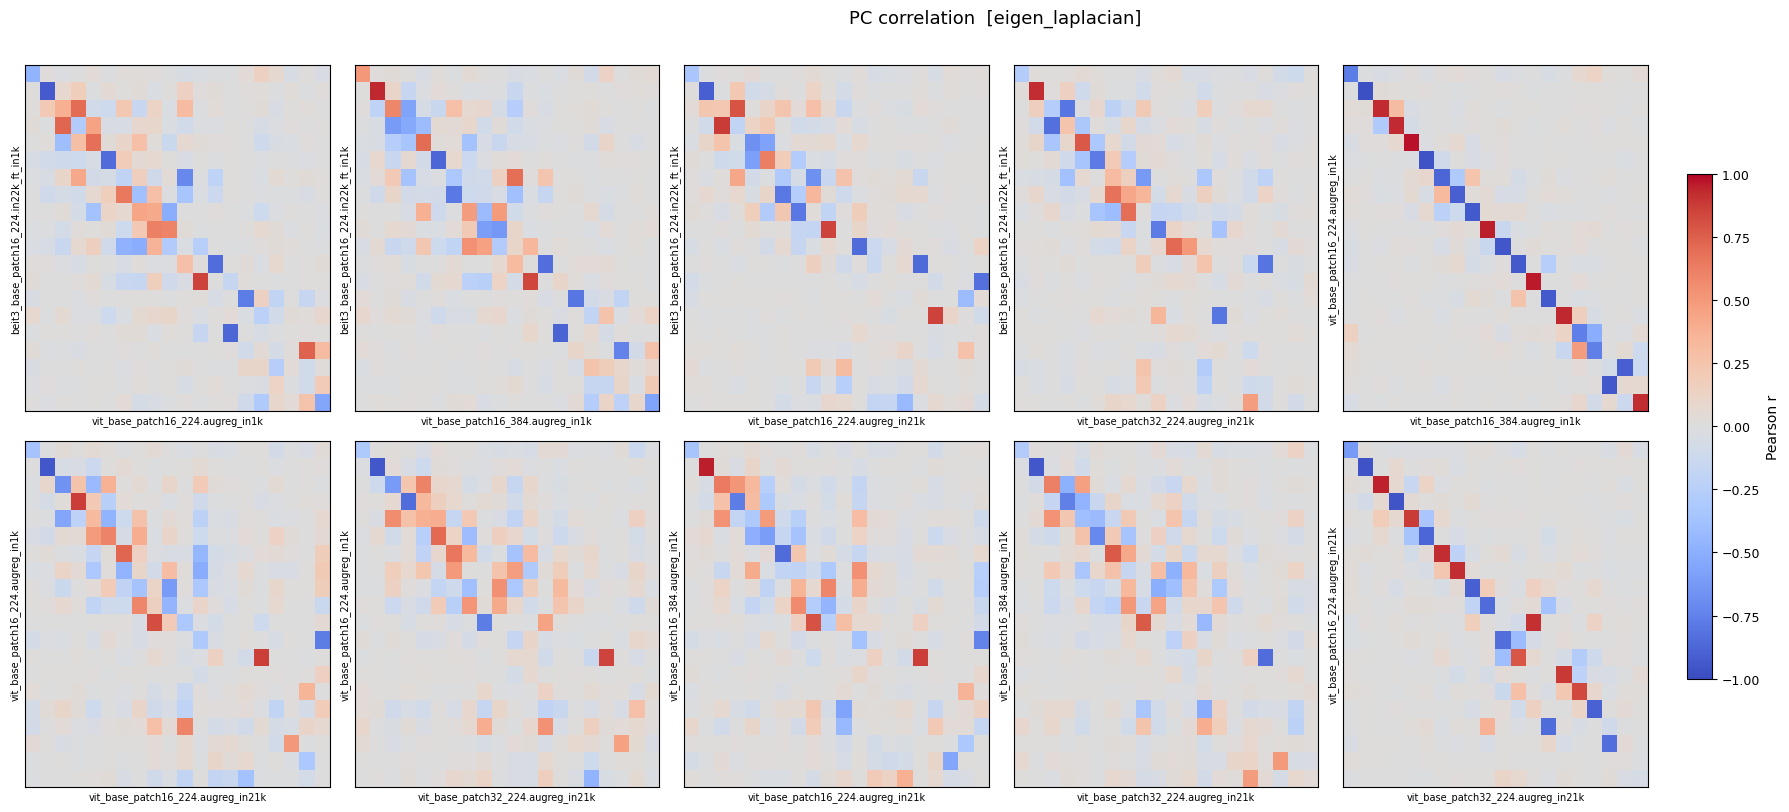

(<Figure size 2000x800 with 11 Axes>,
 array([[<Axes: xlabel='vit_base_patch16_224.augreg_in1k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_384.augreg_in1k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_384.augreg_in1k', ylabel='vit_base_patch16_224.augreg_in1k'>],
        [<Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='vit_base_patch16_224.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='vit_base_patch16_224.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='vit_base_patch16_384.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='vit_base_patch16_384.augreg_in1k'>,
         <Ax

In [ ]:
compare_latents(
    models=models,
    dataset=dataset,
    method='eigen_laplacian',
    n_components=n_components,
    k=k,
)

Loading 5 latent spaces...
Computing 10 correlation matrices...


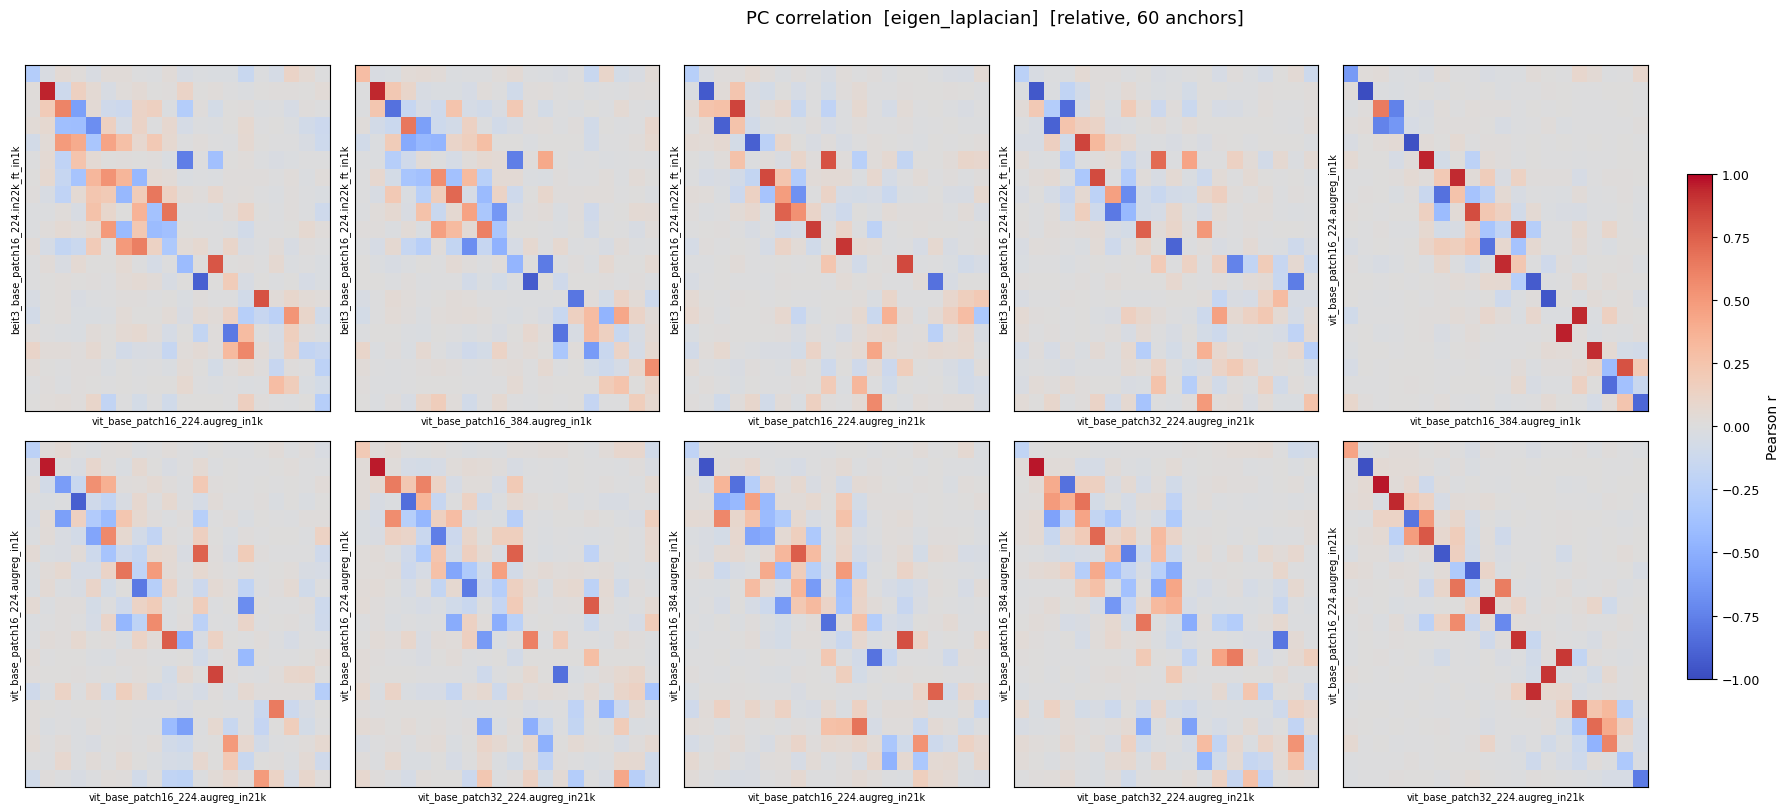

(<Figure size 2000x800 with 11 Axes>,
 array([[<Axes: xlabel='vit_base_patch16_224.augreg_in1k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_384.augreg_in1k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='beit3_base_patch16_224.in22k_ft_in1k'>,
         <Axes: xlabel='vit_base_patch16_384.augreg_in1k', ylabel='vit_base_patch16_224.augreg_in1k'>],
        [<Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='vit_base_patch16_224.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='vit_base_patch16_224.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch16_224.augreg_in21k', ylabel='vit_base_patch16_384.augreg_in1k'>,
         <Axes: xlabel='vit_base_patch32_224.augreg_in21k', ylabel='vit_base_patch16_384.augreg_in1k'>,
         <Ax

In [20]:
compare_latents(
    models=models,
    dataset=dataset,
    method='eigen_laplacian',
    n_components=n_components,
    k=k,
    n_anchors=60,
)